In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import Bio
from Bio import PDB
from Bio.PDB.PDBParser import PDBParser
import pdb_tools
import MDAnalysis as mda
import os
import orient_heme
import re
from natsort import natsorted

In [4]:
paths = [ "../Benchmark/APFD/"]
file_names = ["1aw3.log", "1cyo.log", "1ehb.log", "1mz4.log", "1ycc.log", "2pcb.log"]

In [13]:
paths_ref = ["../Benchmark/Benchmark_logs/Propionate_side_chains/"]
file_names_ref = ["1aw301.log", "1cyo01.log", "1ehb01.log", "1mz401.log", "1ycc01.log", "2pcb01.log"]

In [10]:
fill_dict_occ, fill_dict_unocc = {}, {}

for path in paths:
    for file_name in file_names:
        with open(path+file_name, 'r', encoding='utf-8') as file:
            lines = file.readlines()

        debug = False
        occupied = [k for k in lines if k.startswith(" Alpha  occ. eigenvalues -- ")]
        if debug:
            occupied = occupied[:10]
        occupied = [k.replace(" Alpha  occ. eigenvalues -- ", "") for k in occupied]
        occupied = [k.strip() for k in occupied if k.strip()]
        occupied = [float(num) for k in occupied for num in k.split()]
        occupied_short = occupied[-10:]
        name = file_name.replace(".log", "")
        short_path = path[-7:]
        key = short_path+name
        fill_dict_occ[key] = occupied_short

        unoccupied = [k for k in lines if k.startswith(" Alpha virt. eigenvalues -- ")]
        if debug:
            unoccupied = unoccupied[:10]
        unoccupied = [k.replace(" Alpha virt. eigenvalues -- ", "") for k in unoccupied]
        unoccupied = [k.strip() for k in unoccupied if k.strip()]
        unoccupied = [float(num) for k in unoccupied for num in k.split()]
        unoccupied_short = unoccupied[:10]
        fill_dict_unocc[path+name] = unoccupied_short

    HOMOs, LUMOs = pd.DataFrame(fill_dict_occ), pd.DataFrame(fill_dict_unocc)
print(HOMOs)


   k/APFD/1aw3  k/APFD/1cyo  k/APFD/1ehb  k/APFD/1mz4  k/APFD/1ycc  \
0     -0.22791     -0.23035     -0.23141     -0.22942     -0.23537   
1     -0.22357     -0.22838     -0.22929     -0.22814     -0.23305   
2     -0.21683     -0.22041     -0.22140     -0.22420     -0.22689   
3     -0.21347     -0.19108     -0.20931     -0.21611     -0.22163   
4     -0.20929     -0.18445     -0.20464     -0.18151     -0.19000   
5     -0.18037     -0.18307     -0.18171     -0.17425     -0.18177   
6     -0.17835     -0.17592     -0.17441     -0.17173     -0.17680   
7     -0.17747     -0.17182     -0.16946     -0.16752     -0.17631   
8     -0.16667     -0.16351     -0.16539     -0.16152     -0.17088   
9     -0.16265     -0.15984     -0.16347     -0.11920     -0.13037   

   k/APFD/2pcb  
0     -0.23776  
1     -0.23445  
2     -0.22915  
3     -0.22266  
4     -0.19300  
5     -0.18661  
6     -0.18032  
7     -0.17811  
8     -0.17676  
9     -0.15851  


In [19]:
fill_dict_occ, fill_dict_unocc = {}, {}

for path in paths_ref:
    for file_name in file_names_ref:
        with open(path+file_name, 'r', encoding='utf-8') as file:
            lines = file.readlines()

        debug = False
        occupied = [k for k in lines if k.startswith(" Alpha  occ. eigenvalues -- ")]
        if debug:
            occupied = occupied[:10]
        occupied = [k.replace(" Alpha  occ. eigenvalues -- ", "") for k in occupied]
        occupied = [k.strip() for k in occupied if k.strip()]
        occupied = [float(num) for k in occupied for num in k.split()]
        occupied_short = occupied[-10:]
        name = file_name.replace(".log", "")
        short_path = path[-7:]
        key = short_path+name
        fill_dict_occ[key] = occupied_short

        unoccupied = [k for k in lines if k.startswith(" Alpha virt. eigenvalues -- ")]
        if debug:
            unoccupied = unoccupied[:10]
        unoccupied = [k.replace(" Alpha virt. eigenvalues -- ", "") for k in unoccupied]
        unoccupied = [k.strip() for k in unoccupied if k.strip()]
        unoccupied = [float(num) for k in unoccupied for num in k.split()]
        unoccupied_short = unoccupied[:10]
        fill_dict_unocc[path+name] = unoccupied_short

    HOMOs_ref, LUMOs_ref = pd.DataFrame(fill_dict_occ), pd.DataFrame(fill_dict_unocc)
    HOMOs_ref.to_numpy() - LUMOs_ref.to_numpy() 
print(HOMOs_ref)


[[-0.16768 -0.15416 -0.17517 -0.13644 -0.1309  -0.15906]
 [-0.1649  -0.16529 -0.17954 -0.18264 -0.17316 -0.17565]
 [-0.2032  -0.17598 -0.19074 -0.17986 -0.18061 -0.18098]
 [-0.21868 -0.15731 -0.19739 -0.22864 -0.22548 -0.21844]
 [-0.23035 -0.19877 -0.22237 -0.21177 -0.21468 -0.21571]
 [-0.20696 -0.21089 -0.21322 -0.20649 -0.2146  -0.21012]
 [-0.2072  -0.20878 -0.20553 -0.20665 -0.21716 -0.2127 ]
 [-0.21086 -0.20825 -0.20584 -0.20728 -0.22021 -0.21557]
 [-0.20628 -0.20242 -0.20557 -0.21092 -0.21601 -0.22132]
 [-0.21114 -0.20605 -0.21374 -0.17088 -0.17856 -0.20418]]


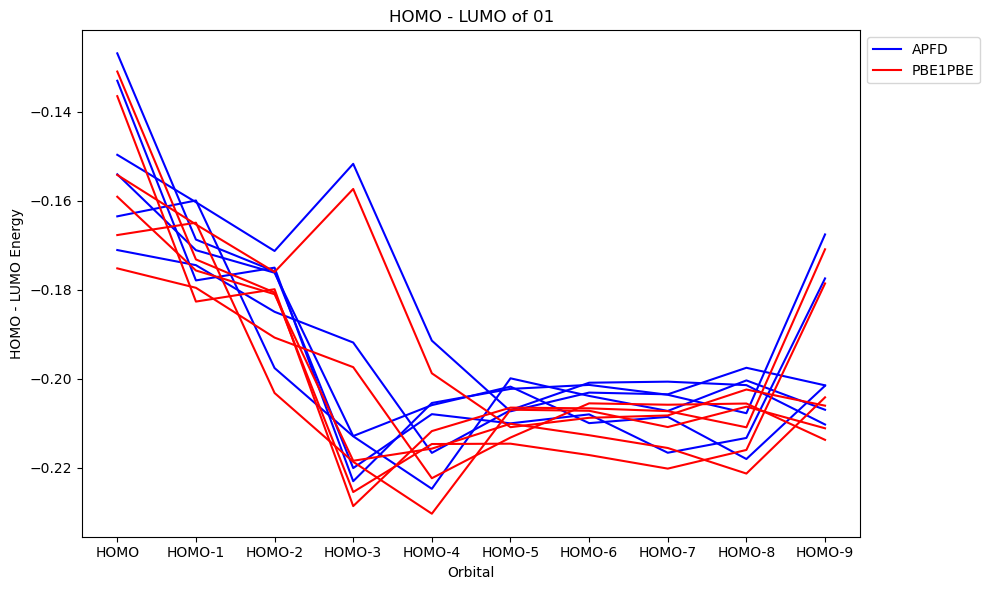

In [40]:
homo_minus_lumo = HOMOs.to_numpy() - LUMOs.to_numpy() 
homo_minus_lumo_ref = HOMOs_ref.to_numpy() - LUMOs_ref.to_numpy() 


#groups = homo_minus_lumo.columns.str[:5]
#unique_groups = groups.unique()

plt.figure(figsize=(10, 6))
ax = plt.gca()  # Get the current Axes object

#for i, group in enumerate(unique_groups):
#    group_columns = [column for column in homo_minus_lumo.columns if column.startswith(group)]
#    group_data = homo_minus_lumo[group_columns]
#    color = cmap(i)  # Use the custom color map
#    group_data.plot(ax=ax, color=color, label='_nolegend_')  # Add '_nolegend_' to prevent labels

tick_labels = ['HOMO', 'HOMO-1', 'HOMO-2', 'HOMO-3', 'HOMO-4', 'HOMO-5', 'HOMO-6', 'HOMO-7', 'HOMO-8', 'HOMO-9']
# Plot homo_minus_lumo
#plt.plot(homo_minus_lumo, label='APFD', color='blue')

line1, a, b, c, d, e = plt.plot(homo_minus_lumo, label='APFD', color='blue')


# Plot homo_minus_lumo_ref
#plt.plot(homo_minus_lumo_ref, label='PBE1PBE', color='red')

line2, d, e, f, g, h = plt.plot(homo_minus_lumo_ref, label='PBE1PBE', color='red')  

plt.xticks(np.arange(10), tick_labels)
plt.xlabel('Orbital')
plt.ylabel('HOMO - LUMO Energy')
plt.title('HOMO - LUMO of 01')
plt.xticks(np.arange(0, 10, step=1))
plt.legend(handles=[line1, line2], labels=['APFD', 'PBE1PBE'], loc='upper left', bbox_to_anchor=(1, 1))

    # Remove the legend
#ax.get_legend().remove()

plt.tight_layout()
plt.show()



In [43]:
gep = homo_minus_lumo - homo_minus_lumo_ref
print(gep)

column_names = ['1aw3', '1cyo', '1ehb', '1mz4', '1ycc', '2pcb']
index_names = [f'HOMO-LUMO-{i}' for i in range(1, 11)]

# Create DataFrame
df = pd.DataFrame(gep, index=index_names, columns=column_names)

# Display the DataFrame
print(df)

[[0.00421 0.00453 0.00412 0.00347 0.00409 0.00504]
 [0.005   0.005   0.00509 0.00476 0.00447 0.00457]
 [0.00561 0.00472 0.0058  0.00485 0.00478 0.00483]
 [0.00574 0.00565 0.00554 0.0056  0.00539 0.00556]
 [0.0056  0.00735 0.0057  0.00632 0.00672 0.00978]
 [0.00706 0.00357 0.00617 0.00421 0.00457 0.00835]
 [0.00334 0.00567 0.00464 0.00527 0.00915 0.00272]
 [0.00362 0.00475 0.00519 0.00368 0.00357 0.007  ]
 [0.00591 0.00489 0.00414 0.00317 0.0027  0.00327]
 [0.00417 0.00457 0.00345 0.00334 0.00113 0.00261]]
                 1aw3     1cyo     1ehb     1mz4     1ycc     2pcb
HOMO-LUMO-1   0.00421  0.00453  0.00412  0.00347  0.00409  0.00504
HOMO-LUMO-2   0.00500  0.00500  0.00509  0.00476  0.00447  0.00457
HOMO-LUMO-3   0.00561  0.00472  0.00580  0.00485  0.00478  0.00483
HOMO-LUMO-4   0.00574  0.00565  0.00554  0.00560  0.00539  0.00556
HOMO-LUMO-5   0.00560  0.00735  0.00570  0.00632  0.00672  0.00978
HOMO-LUMO-6   0.00706  0.00357  0.00617  0.00421  0.00457  0.00835
HOMO-LUMO-7   0.0033